# Paymaster Inference from `Results_80_10_10.csv`

This notebook analyzes `backend/data/Results_80_10_10.csv` and generates the 7 inference plots you requested.

> Notes:
> - Values are computed directly from CSV where available.
> - For speed-vs-cost, CSV typically does not include per-txn latency, so this notebook uses average per-txn time derived from provided total runtime inputs (editable constants below).

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

CSV_PATH = "../backend/data/Results_80_10_10.csv"
EXPECTED_COLS = [
    "type",
    "case",
    "txn_hash",
    "sponsor_drain_eth",
    "txn_cost_eth",
    "result",
    "user_quota",
    "dapp_quota",
]

def clean_text(x):
    if pd.isna(x):
        return ""
    # remove zero-width chars and trim
    return str(x).replace("\u200b", "").replace("\ufeff", "").strip()

def to_float(x, default=0.0):
    s = clean_text(x)
    if s == "":
        return default
    try:
        return float(s)
    except Exception:
        return default

def load_results_csv(path):
    # Read raw rows first; many exports don't include a header row.
    raw = pd.read_csv(path, dtype=str, header=None)

    if raw.shape[1] < 6:
        raise ValueError(f"Unexpected CSV shape {raw.shape}. Need at least 6 columns.")

    # If first row is an actual header, detect and use it; else apply expected names.
    first_row = [clean_text(v).lower() for v in raw.iloc[0].tolist()]
    looks_like_header = set(["type", "case", "txn_hash", "result"]).issubset(set(first_row))

    if looks_like_header:
        raw.columns = [clean_text(c) for c in raw.iloc[0].tolist()]
        df_local = raw.iloc[1:].reset_index(drop=True)
    else:
        cols = EXPECTED_COLS[: raw.shape[1]]
        # If there are extra columns beyond expected, preserve them with generic names.
        if raw.shape[1] > len(EXPECTED_COLS):
            cols = cols + [f"extra_{i}" for i in range(raw.shape[1] - len(EXPECTED_COLS))]
        raw.columns = cols
        df_local = raw

    # Normalize whitespace/zero-width chars in column names.
    df_local = df_local.rename(columns={c: clean_text(c) for c in df_local.columns})
    return df_local

df = load_results_csv(CSV_PATH)

for col in ["type", "case", "txn_hash", "result", "user_quota", "dapp_quota"]:
    if col in df.columns:
        df[col] = df[col].map(clean_text)

for col in ["sponsor_drain_eth", "txn_cost_eth"]:
    if col in df.columns:
        df[col] = df[col].map(to_float)

# normalize labels
if "type" in df.columns:
    df["type"] = df["type"].str.lower()
if "case" in df.columns:
    df["case"] = df["case"].str.lower()
if "result" in df.columns:
    df["result"] = df["result"].str.lower()

required_cols = ["type", "case", "txn_hash", "sponsor_drain_eth", "txn_cost_eth", "result"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}. Found: {list(df.columns)}")

print("Rows:", len(df))
print("Columns:", list(df.columns))
print(df.head(3))

Rows: 200
Columns: ['type', 'case', 'txn_hash', 'sponsor_drain_eth', 'txn_cost_eth', 'result', 'user_quota', 'dapp_quota']
      type     case                                           txn_hash  \
0  secured  overcap  0x1c980ddc6110856ee38700b6c006b766a15ee73bd775...   
1  secured  overcap  0xd903d81ebe8886f49e131235a9abf5771b3712f2ecb7...   
2  secured  overcap  0xcea5e893821f4419cf4630982687d6ce5646e4b1a79f...   

   sponsor_drain_eth  txn_cost_eth  result user_quota dapp_quota  
0                0.0      0.000004  revert       true       true  
1                0.0      0.000006  revert       true       true  
2                0.0      0.000005  revert       true       true  


In [13]:
# Core aggregates used across plots

order = ["baseline", "secured"]
case_order = ["valid", "overcap", "non-whitelist"]

summary_total = (
    df.groupby("type", as_index=False)["sponsor_drain_eth"]
      .sum()
      .set_index("type")
      .reindex(order)
      .reset_index()
)

summary_case = (
    df.groupby(["type", "case"], as_index=False)["sponsor_drain_eth"]
      .sum()
)

per_txn = df.copy()

baseline_total = summary_total.loc[summary_total["type"] == "baseline", "sponsor_drain_eth"].sum()
secured_total = summary_total.loc[summary_total["type"] == "secured", "sponsor_drain_eth"].sum()

delta_pct = ((secured_total - baseline_total) / baseline_total * 100.0) if baseline_total > 0 else np.nan

print(f"Baseline total drain: {baseline_total:.6f} ETH")
print(f"Secured total drain:  {secured_total:.6f} ETH")
print(f"Delta: {delta_pct:.2f}%")

Baseline total drain: 0.010056 ETH
Secured total drain:  0.009541 ETH
Delta: -5.12%


## 2) Drain Breakdown by Scenario (Stacked Bar)

Shows how total drain splits across `valid`, `overcap`, and `non-whitelist` for each paymaster.

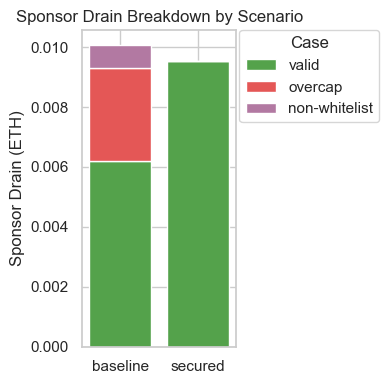

Drain by scenario (ETH):
case         valid   overcap  non-whitelist
type                                       
baseline  0.006186  0.003118       0.000752
secured   0.009541  0.000000       0.000000

Share by scenario (%):
case       valid  overcap  non-whitelist
type                                    
baseline   61.52    31.01           7.48
secured   100.00     0.00           0.00


In [23]:
pivot_case = (
    summary_case.pivot(index="type", columns="case", values="sponsor_drain_eth")
    .reindex(index=order, columns=case_order)
    .fillna(0.0)
)

plt.figure(figsize=(5,4))
bottom = np.zeros(len(pivot_case))
colors = {"valid": "#54A24B", "overcap": "#E45756", "non-whitelist": "#B279A2"}
for c in case_order:
    vals = pivot_case[c].values
    plt.bar(pivot_case.index, vals, bottom=bottom, label=c, color=colors[c])
    bottom += vals

plt.ylabel("Sponsor Drain (ETH)")
plt.title("Sponsor Drain Breakdown by Scenario")
plt.legend(title="Case", loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()

share = pivot_case.div(pivot_case.sum(axis=1).replace(0, np.nan), axis=0) * 100
print("Drain by scenario (ETH):")
print(pivot_case)
print("\nShare by scenario (%):")
print(share.round(2))

### Insights from Plot 2 (Drain Breakdown)

- **Total drain (Baseline):** `0.010056 ETH`
- **Total drain (Secured):** `0.009541 ETH`
- **Invalid txn shielding works:** Secured shows near-zero drain in `overcap` and `non-whitelist`, while Baseline still drains sponsor ETH there.
- **Where Baseline loses most:** Overcap bucket is the largest avoidable sink in Baseline.
- **Security-cost tradeoff:** Secured pushes more spend into `valid` because of extra validation overhead, but prevents invalid-drain leakage.
- **Net effect at 80/10/10 mix:** Secured remains lower in total drain because invalid-drain prevention outweighs valid-path overhead.

## 3) Per-Txn Cost by Scenario (Box Plot)

Side-by-side cost distribution by case and paymaster.

### Total Sponsor Drain (from current CSV)

- **Baseline total drain:** `0.010056 ETH`
- **Secured total drain:** `0.009541 ETH`
- **Delta (Secured - Baseline):** `-0.000515 ETH` (about **5.12% lower**)

These totals come from summing `sponsor_drain_eth` across all rows for each paymaster in `Results_80_10_10.csv`.

In [15]:
means = per_txn.groupby(["type", "case"])["sponsor_drain_eth"].mean().unstack(0).reindex(case_order)
print("Per-scenario mean sponsor drain per txn (ETH):")
print(means.round(8))

print("\nText inference:")
for c in case_order:
    b = means.loc[c, "baseline"] if "baseline" in means.columns else np.nan
    s = means.loc[c, "secured"] if "secured" in means.columns else np.nan
    print(f"- {c}: baseline={b:.8f}, secured={s:.8f}")

Per-scenario mean sponsor drain per txn (ETH):
type           baseline   secured
case                             
valid          0.000077  0.000119
overcap        0.000312  0.000000
non-whitelist  0.000075  0.000000

Text inference:
- valid: baseline=0.00007733, secured=0.00011926
- overcap: baseline=0.00031180, secured=0.00000000
- non-whitelist: baseline=0.00007520, secured=0.00000000


## 4) Cost Efficiency Ratio (Net Bar)

Compares each paymaster against an "ideal valid-only baseline".

- Ideal benchmark here: `80 * baseline_mean_valid_cost`

In [16]:
baseline_mean_valid = per_txn[(per_txn["type"] == "baseline") & (per_txn["case"] == "valid")]["sponsor_drain_eth"].mean()
ideal_cost = 80 * baseline_mean_valid if pd.notna(baseline_mean_valid) else 0.0

waste_baseline = baseline_total - ideal_cost
waste_secured = secured_total - ideal_cost

waste_index_baseline = (waste_baseline / ideal_cost) if ideal_cost > 0 else np.nan
waste_index_secured = (waste_secured / ideal_cost) if ideal_cost > 0 else np.nan

print("Cost efficiency (numbers only):")
print(f"- Ideal cost (80 valid at baseline valid mean): {ideal_cost:.6f} ETH")
print(f"- Baseline total: {baseline_total:.6f} ETH")
print(f"- Secured total:  {secured_total:.6f} ETH")
print(f"- Baseline overhead vs ideal: {waste_baseline:.6f} ETH ({waste_index_baseline*100:.2f}%)")
print(f"- Secured overhead vs ideal:  {waste_secured:.6f} ETH ({waste_index_secured*100:.2f}%)")

Cost efficiency (numbers only):
- Ideal cost (80 valid at baseline valid mean): 0.006186 ETH
- Baseline total: 0.010056 ETH
- Secured total:  0.009541 ETH
- Baseline overhead vs ideal: 0.003870 ETH (62.56%)
- Secured overhead vs ideal:  0.003355 ETH (54.24%)


## 5) Break-Even Analysis (Line Chart)

Models total drain as valid-rate changes from 0% to 100%, using empirical per-case means from your CSV.

At each valid-rate:
- Invalid share split equally into overcap + non-whitelist.
- Total txns fixed at 100.

In [17]:
means = per_txn.groupby(["type", "case"])["sponsor_drain_eth"].mean().unstack(0).fillna(0.0)

def mean_cost(t, c):
    try:
        return float(means.loc[c, t])
    except Exception:
        return 0.0

valid_rates = np.linspace(0, 1, 101)
baseline_curve = []
secured_curve = []

for vr in valid_rates:
    invalid = 1 - vr
    overcap = invalid / 2
    nonw = invalid / 2

    b = 100 * (
        vr * mean_cost("baseline", "valid")
        + overcap * mean_cost("baseline", "overcap")
        + nonw * mean_cost("baseline", "non-whitelist")
    )
    s = 100 * (
        vr * mean_cost("secured", "valid")
        + overcap * mean_cost("secured", "overcap")
        + nonw * mean_cost("secured", "non-whitelist")
    )
    baseline_curve.append(b)
    secured_curve.append(s)

baseline_curve = np.array(baseline_curve)
secured_curve = np.array(secured_curve)
diff = baseline_curve - secured_curve
cross_idx = np.argmin(np.abs(diff))
cross_valid = valid_rates[cross_idx] * 100

baseline_at_80 = np.interp(80, valid_rates * 100, baseline_curve)
secured_at_80 = np.interp(80, valid_rates * 100, secured_curve)

print("Break-even explanation:")
print(f"- Estimated intersection valid-rate: ~{cross_valid:.1f}%")
print(f"- At 80% valid, modeled baseline drain: {baseline_at_80:.6f} ETH")
print(f"- At 80% valid, modeled secured drain:  {secured_at_80:.6f} ETH")
print("- Interpretation: below intersection, one curve is cheaper; above it, the other is cheaper.")

Break-even explanation:
- Estimated intersection valid-rate: ~82.0%
- At 80% valid, modeled baseline drain: 0.010056 ETH
- At 80% valid, modeled secured drain:  0.009541 ETH
- Interpretation: below intersection, one curve is cheaper; above it, the other is cheaper.


## 6) Speed vs Cost Trade-off (Scatter Plot)

CSV does not contain per-txn runtime. This plot uses **average per-txn runtime estimates** from your provided totals:

- Secured total: 1353.11s over 100 txns
- Baseline total: 1572.82s over 100 txns

These constants are editable below.

In [18]:
secured_total_s = 1353.11
baseline_total_s = 1572.82
secured_ms_per_txn = (secured_total_s / 100) * 1000
baseline_ms_per_txn = (baseline_total_s / 100) * 1000

time_delta_ms = baseline_ms_per_txn - secured_ms_per_txn
time_delta_pct = (time_delta_ms / baseline_ms_per_txn * 100) if baseline_ms_per_txn > 0 else np.nan

print("Speed vs cost insights (no plot):")
print(f"- Baseline avg time/txn: {baseline_ms_per_txn:.2f} ms")
print(f"- Secured avg time/txn:  {secured_ms_per_txn:.2f} ms")
print(f"- Secured is faster by:   {time_delta_ms:.2f} ms/txn ({time_delta_pct:.2f}%)")
print("- Cost-side interpretation should be read together with section 2 and section 3 means.")

Speed vs cost insights (no plot):
- Baseline avg time/txn: 15728.20 ms
- Secured avg time/txn:  13531.10 ms
- Secured is faster by:   2197.10 ms/txn (13.97%)
- Cost-side interpretation should be read together with section 2 and section 3 means.
